# **Classification types**

 - Binary Classification: 2 classes only (e.g. spam vs not spam).
 - Multi-class Classification: >2 Mmutually exclusive classes (e.g., classify a digit as 0-6).
 - Multi-label Classification: 1 question, many possible answers at once → multiple labels can be true together.

# **Set Up Your Python Environment and dataset**

X shape: (1000, 2)
y shape: (1000,)


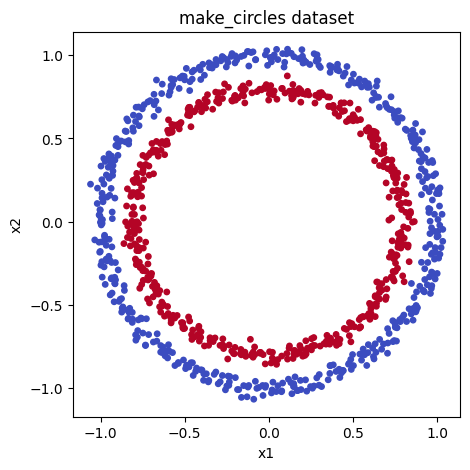

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 2. Create concentric circles (non-linear decision boundary)
samples = 1000
X, y = make_circles(n_samples=samples, noise=0.03, random_state=42)

print('X shape:', X.shape)   # (1000, 2)
print('y shape:', y.shape)   # (1000,)

# Visualize
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=15)
plt.title("make_circles dataset")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

# **Basic neural network**

In [8]:
# Building a very simple model (underfits on purpose)
tf.random.set_seed(42)

tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(10)
])

basic_model.compile(optimizer="sgd",
                    loss="binary_crossentropy",
                    metrics=["accuracy"])

history_basic = basic_model.fit(X, y, epochs=50, verbose=0)
print("Basic model final accuracy:", history_basic.history["accuracy"][-1])

Basic model final accuracy: 0.4959999918937683


# **Improve the model**

In [3]:
tf.random.set_seed(42)

better_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

better_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

history_better = better_model.fit(X, y, epochs=100, verbose=0)
print("Improved model final accuracy:", history_better.history['accuracy'][-1])

Improved model final accuracy: 1.0


# **Decision boundary plotter**

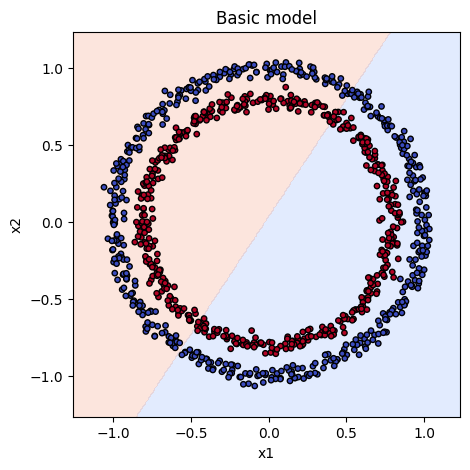

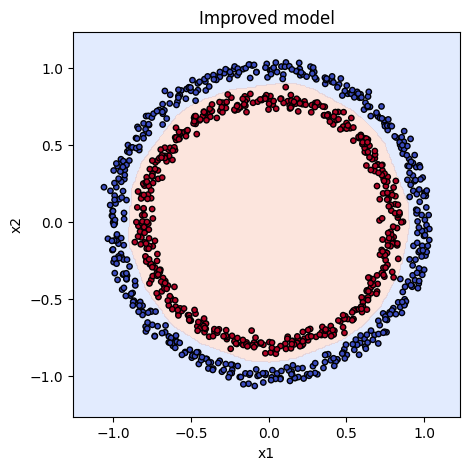

In [4]:
def plot_decision_boundary(model, X, y, title="Decision boundary"):
    # Create a grid over the feature space
    x_min, x_max = X[:,0].min()-0.2, X[:,0].max()+0.2
    y_min, y_max = X[:,1].min()-0.2, X[:,1].max()+0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Predict probabilities then class
    probs = model.predict(grid, verbose=0).reshape(xx.shape)
    preds = (probs >= 0.5).astype(int)

    # Plot
    plt.figure(figsize=(5,5))
    plt.contourf(xx, yy, preds, alpha=0.25, cmap='coolwarm', levels=[-1,0,1])
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=15, edgecolor='k')
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

# Compare
plot_decision_boundary(basic_model, X, y, "Basic model")
plot_decision_boundary(better_model, X, y, "Improved model")

# **Activation functions: ReLU vs Activation functions: ReLU vs Sigmoid**

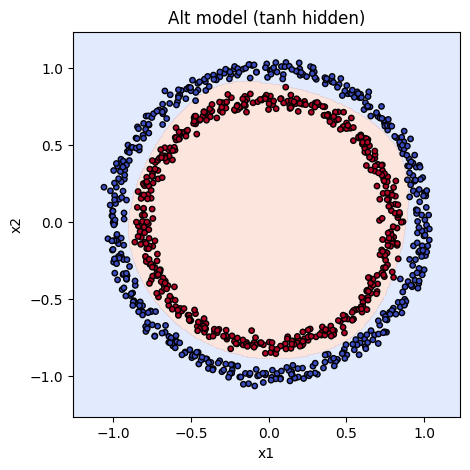

In [5]:
alt_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(16, activation='tanh'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
alt_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
alt_model.fit(X, y, epochs=100, verbose=0)
plot_decision_boundary(alt_model, X, y, "Alt model (tanh hidden)")

# **Train/test split (80/20)**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 1.000


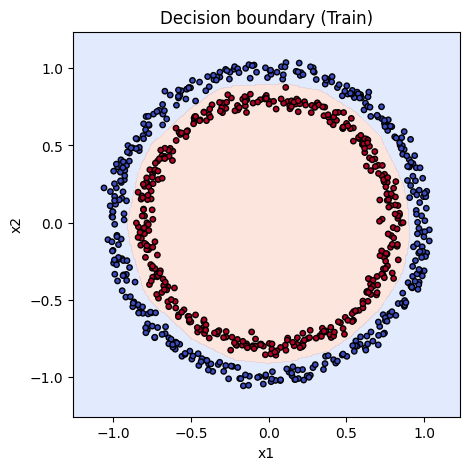

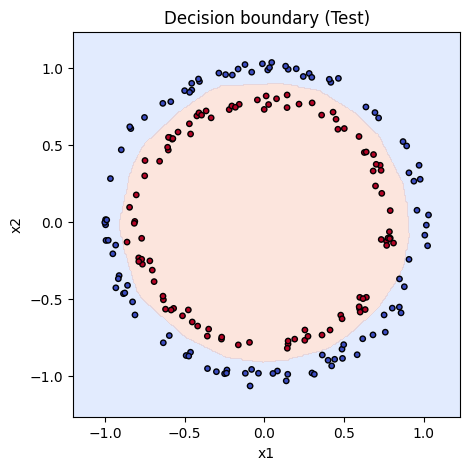

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tf.random.set_seed(42)
split_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
split_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_split = split_model.fit(X_train, y_train, epochs=100, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = split_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundaries on train vs test
plot_decision_boundary(split_model, X_train, y_train, "Decision boundary (Train)")
plot_decision_boundary(split_model, X_test,  y_test,  "Decision boundary (Test)")

# **Final Evalution curves**

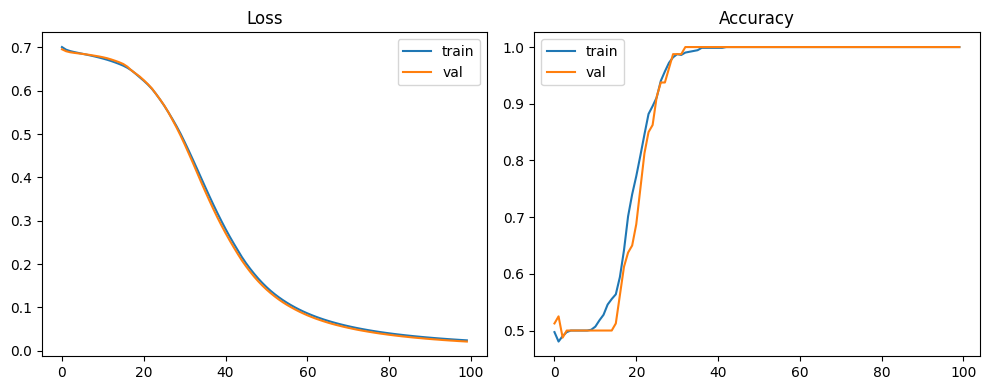

In [7]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist_split.history['loss'], label='train')
plt.plot(hist_split.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_split.history['accuracy'], label='train')
plt.plot(hist_split.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

# **Key Takeaways**

From this exercise, I learned how important it is to visualize data before building models. Seeing the data’s shape helps decide whether a linear or non-linear model is needed. I also saw how adding layers and using activation functions like ReLU help the network capture more complex patterns. Optimizers such as Adam make training smoother and faster compared to SGD. Evaluating both training and test performance helped me understand overfitting and underfitting — the goal is for both accuracies to stay close, showing good generalization. Finally, the decision boundary visualization made it clear how the model “thinks” — it shows whether the network is learning simple or more flexible patterns to separate the data.
